In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# make plots look nicer
sns.set(style="whitegrid")

In [2]:
def wrangle(filepath):
    # load data
    df = pd.read_csv(filepath)

    # drop duplicates
    df = df.drop_duplicates()

    # check missing values
    df = df.dropna()

    # optional: remove highly correlated features
    corr = df.corr(numeric_only=True)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
    df = df.drop(columns=to_drop)

    return df

In [3]:
df = wrangle("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


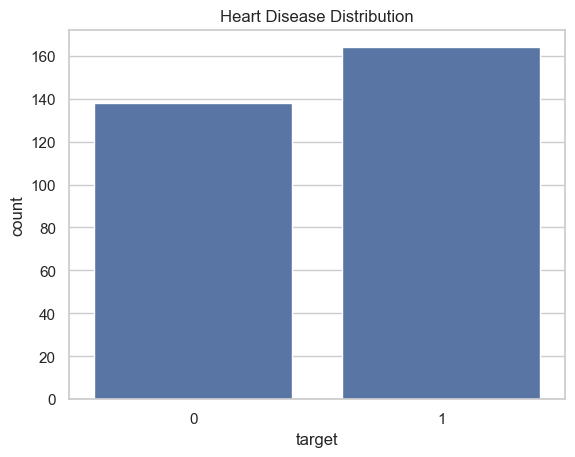

In [5]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

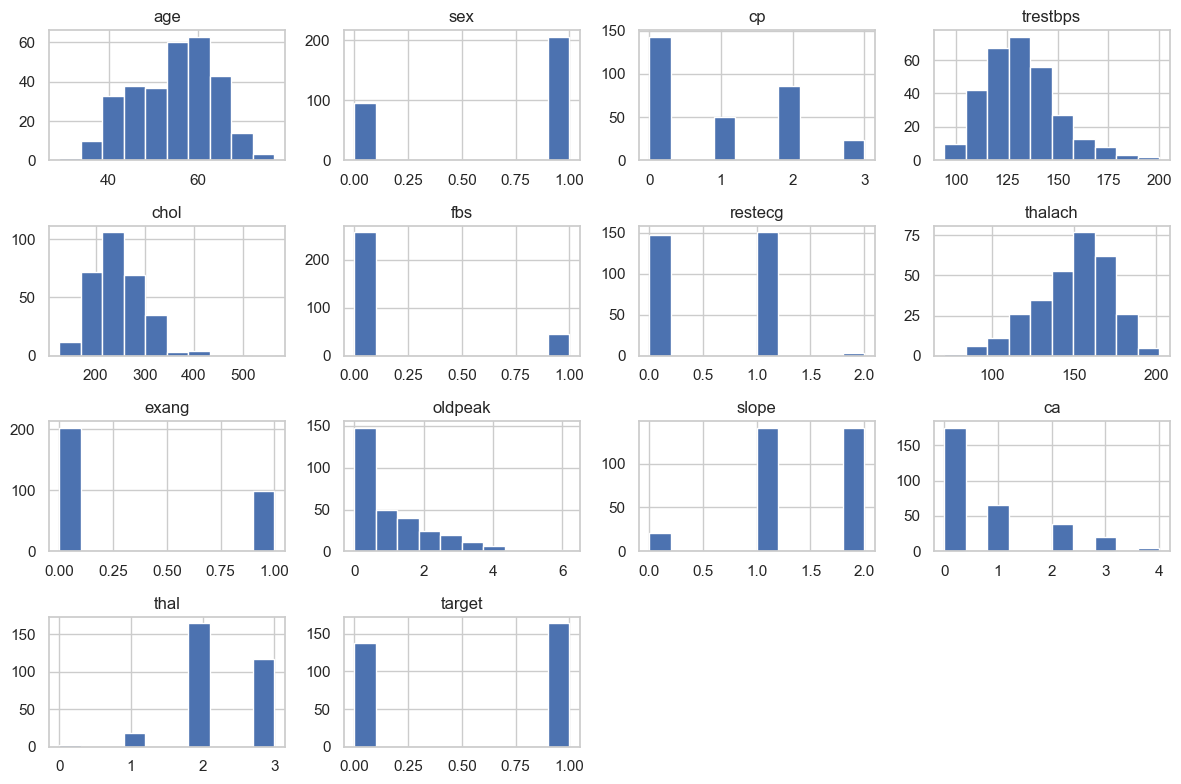

In [6]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

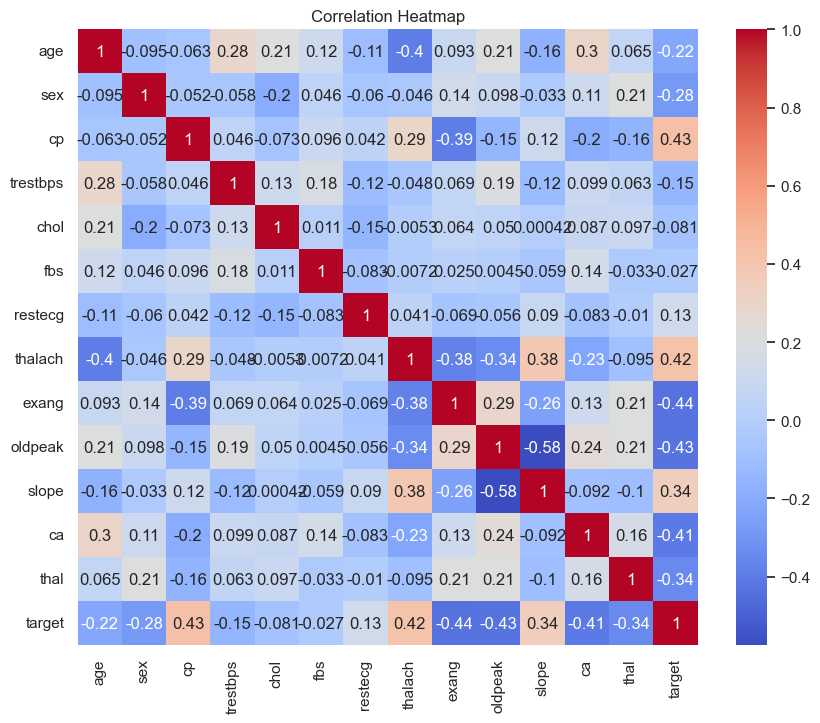

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

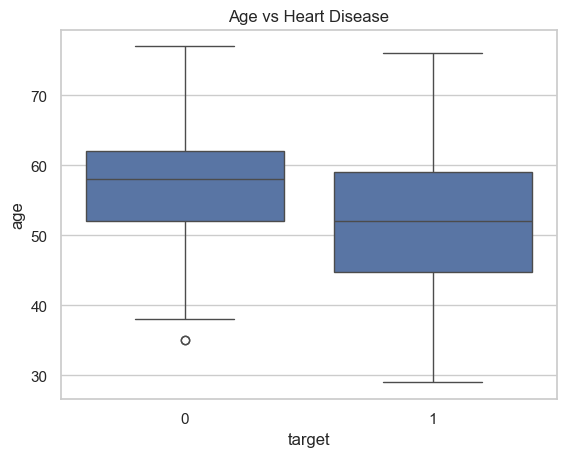

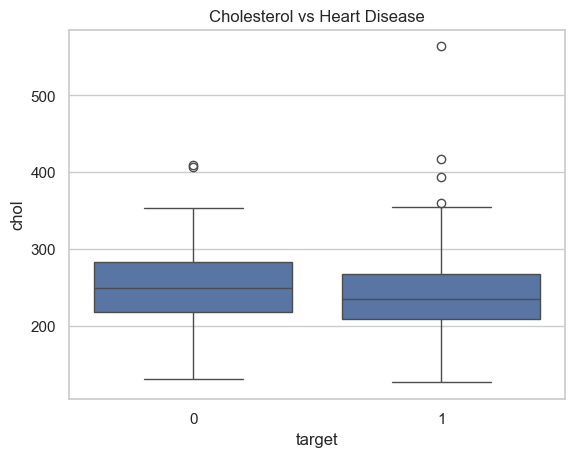

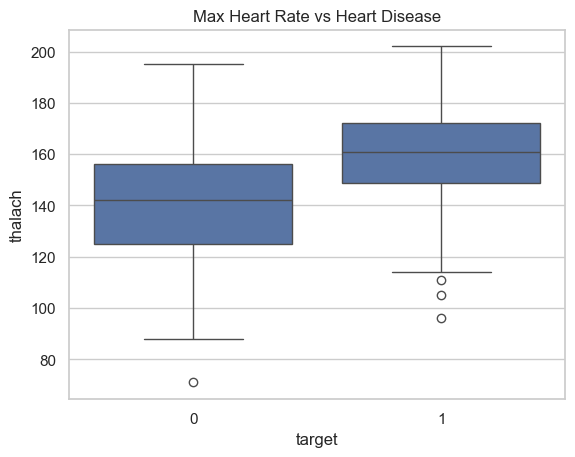

In [8]:
sns.boxplot(x="target", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

sns.boxplot(x="target", y="thalach", data=df)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

In [9]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(241, 13) (61, 13)


In [35]:
### Baseline Model
#Before building the logistic regression model, I created a baseline model for comparison. The baseline predicts the majority class from the training data for every patient. This helps show whether the final model performs better than a simple prediction method.

In [10]:
# baseline = majority class
baseline = y_train.mode()[0]

baseline_preds = [baseline] * len(y_test)

print("Baseline accuracy:", (baseline_preds == y_test).mean())

Baseline accuracy: 0.47540983606557374


In [34]:
### Logistic Regression Model
#Logistic regression was used because this is a binary classification problem. The model predicts whether a patient has heart disease or does not have heart disease based on the input features.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [33]:
### Predictions
#After training the logistic regression model, I used it to make predictions on the test data. These predictions are compared to the actual test labels to evaluate how well the model performs.

In [23]:
y_pred = model.predict(X_test)

In [32]:
### Model Evaluation Metrics
#The model was evaluated using accuracy, precision, recall, and F1-score. Accuracy measures overall correct predictions, precision measures how many predicted heart disease cases were actually correct, recall measures how many real heart disease cases were found, and F1-score balances precision and recall.

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7704918032786885
Precision: 0.7027027027027027
Recall: 0.896551724137931
F1 Score: 0.7878787878787878


In [31]:
### Confusion Matrix
#The confusion matrix shows how many predictions were correct and incorrect. It helps identify true positives, true negatives, false positives, and false negatives.

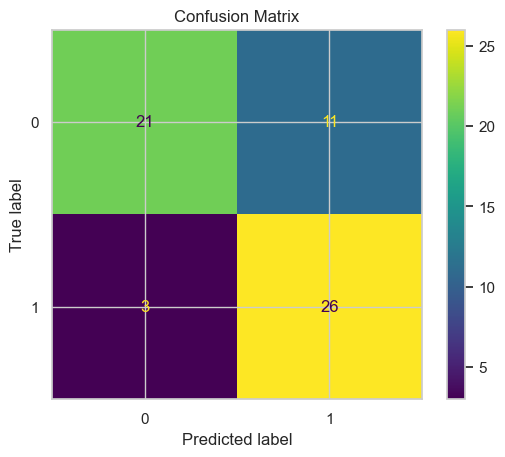

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [30]:
### Classification Report
#The classification report gives a summary of the model’s precision, recall, F1-score, and support for each class. This provides a more detailed view of how well the model performs for both patients with and without heart disease.

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



In [36]:
# The logistic regression model achieved about 77% accuracy.
# The recall score was high at about 90%, meaning the model correctly identified most patients with heart disease.
# This is important because missing a heart disease case could be more serious than a false alarm.
# The F1-score was about 79%, showing a good balance between precision and recall.